# Part 2. A model that knows what it does not know

The idea from the lecture: instead of guessing the function with a single curve, we keep a whole distribution of curves that are consistent with the data, and we track how unsure we are at every input. Where we have measured, the model is confident. Where we have not, it admits it.

That object is a Gaussian process. You will build one in `blackbox/gp.py`. Two methods are left open, the kernel and the posterior. This notebook gives you the formulas and lets you test each piece as you go.

We learn it on a cheap one-dimensional function so you can see everything on a single plot. The expensive twelve-knob machine comes back in part 4.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for cand in [here, *here.parents]:
    if (cand / "blackbox").is_dir():
        if str(cand) not in sys.path:
            sys.path.insert(0, str(cand))
        break

import numpy as np
import matplotlib.pyplot as plt
from blackbox import plotting
plotting.use_clean_style()

%load_ext autoreload
%autoreload 2

from blackbox import forrester
from blackbox.gp import GaussianProcess

## The test function

We use the Forrester function on the interval from 0 to 1, scaled so its values have roughly unit spread. The scaling is cosmetic: it just keeps the model's default settings sensible, so we do not have to fuss over them. We are allowed to draw the whole curve here because it is cheap. Remember that for the real machine you never get to see this, you only get the dots.

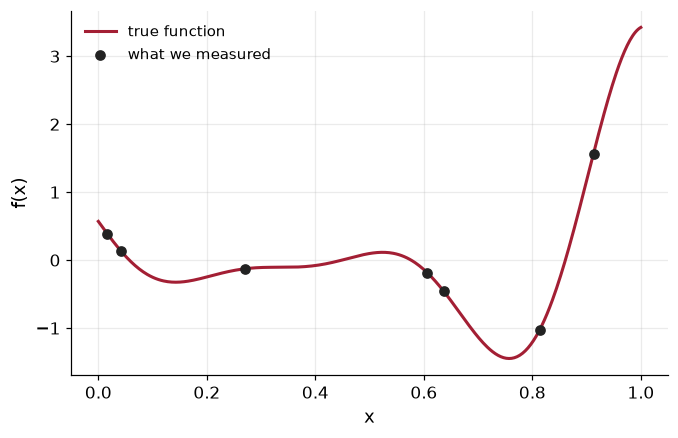

In [2]:
xx = np.linspace(0, 1, 400)
_raw = forrester(xx)
shift, spread = _raw.mean(), _raw.std()

def f(x):
    return (forrester(np.asarray(x, dtype=float)) - shift) / spread

rng = np.random.default_rng(0)
X_obs = np.sort(rng.uniform(0, 1, size=7))
y_obs = f(X_obs)

plt.plot(xx, f(xx), color=plotting.TRUTH, label="true function")
plt.scatter(X_obs, y_obs, color=plotting.DATA, zorder=5, label="what we measured")
plt.xlabel("x"); plt.ylabel("f(x)"); plt.legend(); plt.show()

## Step 1. The kernel

A Gaussian process is built on one idea: inputs that are close together should give outputs that are close together. The kernel is the function that says how close two inputs are. We use the squared-exponential kernel,

$$ k(a, b) = \sigma_f^2 \, \exp\!\left(-\tfrac{1}{2}\,\frac{\lVert a - b\rVert^2}{\ell^2}\right). $$

Here $\ell$ is the lengthscale and $\sigma_f^2$ is the signal variance.

Open `blackbox/gp.py` and fill in the `kernel` method. The docstring there gives a clean way to compute all the pairwise distances at once. Save the file, then run the test below.

shape: (400, 400) (should be 400 by 400)
diagonal value: 1.0 (should equal signal_var = 1.0)
symmetric: True


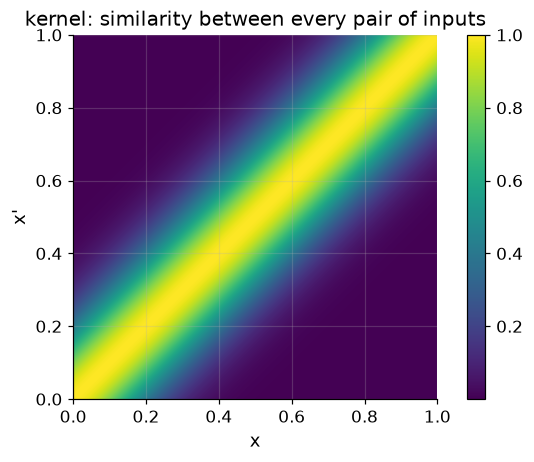

In [3]:
gp = GaussianProcess(lengthscale=0.15)
K = gp.kernel(xx[:, None], xx[:, None])
print("shape:", K.shape, "(should be 400 by 400)")
print("diagonal value:", round(float(K[0, 0]), 3), "(should equal signal_var = 1.0)")
print("symmetric:", np.allclose(K, K.T))

plt.imshow(K, origin="lower", extent=[0, 1, 0, 1])
plt.title("kernel: similarity between every pair of inputs")
plt.xlabel("x"); plt.ylabel("x'"); plt.colorbar(); plt.show()

## Step 2. Samples from the prior

Before any data, the model is a distribution over functions. We can draw from it. The `sample_prior` helper is already written and uses your kernel. Notice how the lengthscale sets the character of the functions: small means wiggly, large means smooth.

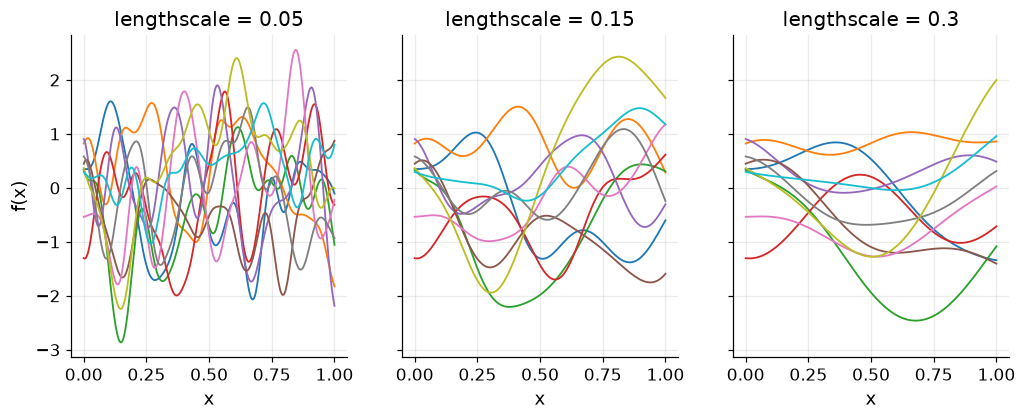

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.8), sharey=True)
for ax, ell in zip(axes, [0.05, 0.15, 0.3]):
    gp = GaussianProcess(lengthscale=ell)
    draws = gp.sample_prior(xx[:, None], n_samples=10, rng=np.random.default_rng(1))
    for d in draws:
        ax.plot(xx, d, lw=1.2)
    ax.set_title("lengthscale = " + str(ell)); ax.set_xlabel("x")
axes[0].set_ylabel("f(x)"); plt.show()

## Step 3. Conditioning, which is the whole engine

Now we use the data. Conditioning a Gaussian process on observations turns the prior into a posterior: a new mean and a new uncertainty that pass through (or near) the measured points and grow between them.

With the training covariance factored once in `fit`, the posterior at test points $X_*$ is

$$ \text{mean} = K_*^\top \alpha, \qquad \text{var} = \sigma_f^2 - \sum_i v_i^2, \quad v = L^{-1} K_*, $$

where $K_* = k(X_\text{train}, X_*)$, $L$ is the Cholesky factor of the training covariance, and $\alpha = K^{-1} y$. Fill in the `posterior` method in `blackbox/gp.py`, then run the cell.

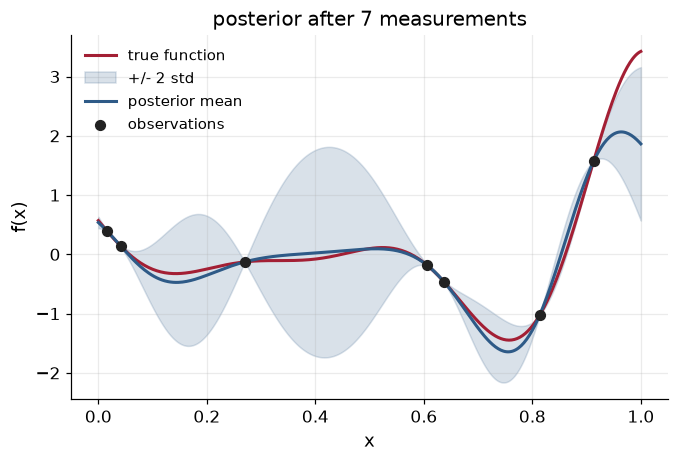

In [5]:
gp = GaussianProcess(lengthscale=0.101, noise_var=1e-4).fit(X_obs, y_obs)
mean, std = gp.posterior(xx[:, None])

plotting.plot_gp_1d(xx, mean, std, X_obs, y_obs, truth=f(xx),
                    title=f"posterior after {len(X_obs)} measurements")
plt.show()

The band is thin at the dots and fat in the gaps. That fat region is the model telling you where it has no idea, and that is exactly where it can be worth measuring. Add one measurement in the widest gap and watch the band collapse there.

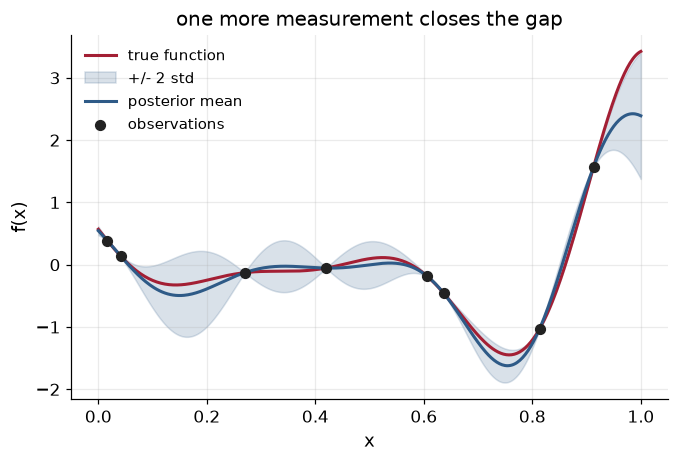

In [6]:
x_new = 0.42
X2 = np.append(X_obs, x_new)
y2 = np.append(y_obs, f(x_new))

gp = GaussianProcess(lengthscale=0.12, noise_var=1e-4).fit(X2, y2)
mean, std = gp.posterior(xx[:, None])
plotting.plot_gp_1d(xx, mean, std, X2, y2, truth=f(xx),
                    title="one more measurement closes the gap")
plt.show()

## Step 4. The lengthscale matters

The lengthscale is the most consequential setting. Too short and the model trusts nothing between points. Too long and it smooths over real structure. Look at three choices.

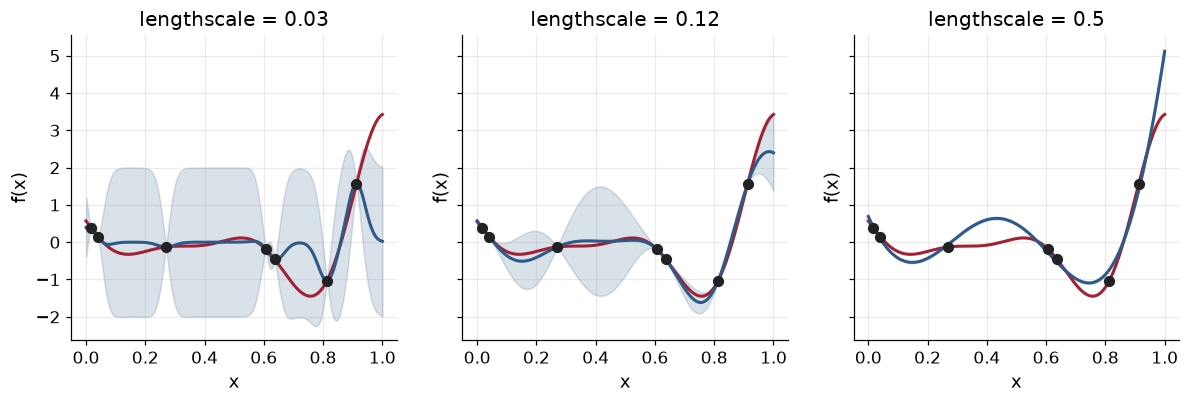

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharey=True)
for ax, ell in zip(axes, [0.03, 0.12, 0.5]):
    gp = GaussianProcess(lengthscale=ell, noise_var=1e-4).fit(X_obs, y_obs)
    mean, std = gp.posterior(xx[:, None])
    plotting.plot_gp_1d(xx, mean, std, X_obs, y_obs, truth=f(xx), ax=ax)
    ax.set_title("lengthscale = " + str(ell)); ax.legend().set_visible(False)
plt.show()

## Step 5 (bonus). Let the data choose the lengthscale

You do not have to pick the lengthscale by eye. The marginal likelihood scores how well a given lengthscale explains the data, with a built in penalty for needless wiggliness. With a few more measurements to go on, maximizing it lands on a sensible value. Implement `log_marginal_likelihood` in `blackbox/gp.py`, then run the scan.

chosen lengthscale: 0.101


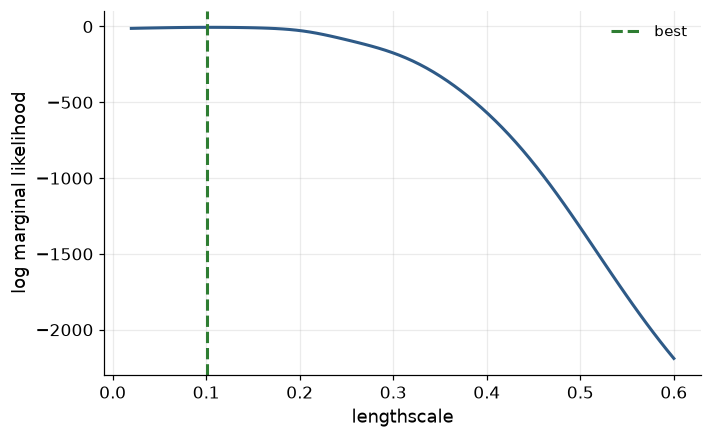

In [8]:
rng_b = np.random.default_rng(1)
X_lml = np.sort(rng_b.uniform(0, 1, size=12))
y_lml = f(X_lml)
ell_grid = np.linspace(0.02, 0.6, 80)

# TODO: implement log_marginal_likelihood in blackbox/gp.py, then fit a GP at
# each lengthscale in ell_grid (use noise_var=1e-3) and collect the value into
# `lml`. Replace the placeholder line below with that scan.
lml = np.array([
    GaussianProcess(lengthscale=ell, noise_var=1e-3).fit(X_lml, y_lml).log_marginal_likelihood()
    for ell in ell_grid
])


best_ell = ell_grid[np.argmax(lml)]
print("chosen lengthscale:", round(best_ell, 3))
plt.plot(ell_grid, lml, color=plotting.MODEL)
plt.axvline(best_ell, color=plotting.PICK, ls="--", label="best")
plt.xlabel("lengthscale"); plt.ylabel("log marginal likelihood")
plt.legend(); plt.show()

## Step 6. Noisy measurements

Real detectors are noisy. The `noise_var` setting tells the model not to trust each point exactly, so the curve passes near the data instead of through it. Compare a near-zero noise fit with an honest one on the same noisy data.

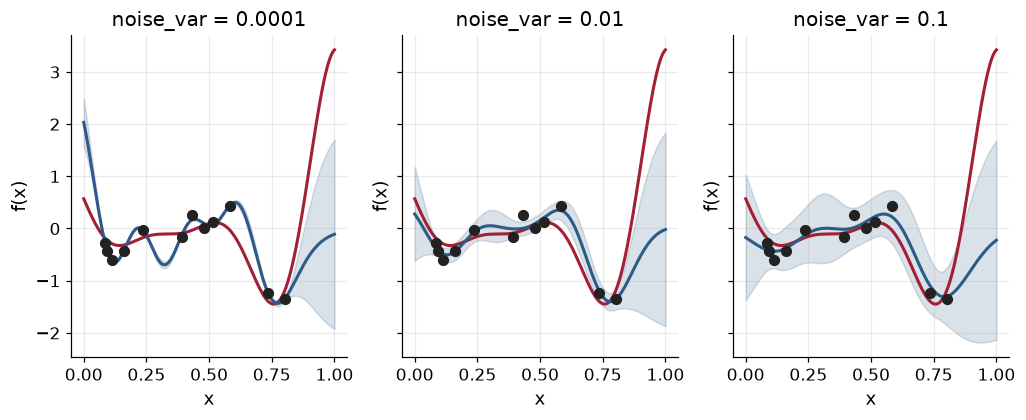

In [9]:
rng_n = np.random.default_rng(3)
Xn = np.sort(rng_n.uniform(0, 1, size=12))
yn = f(Xn) + rng_n.normal(0, 0.3, size=Xn.shape)

fig, axes = plt.subplots(1, 3, figsize=(11, 3.8), sharey=True)
for ax, nv in zip(axes, [1e-4, 0.01, 0.1]):
    gp = GaussianProcess(lengthscale=0.12, noise_var=nv).fit(Xn, yn)
    mean, std = gp.posterior(xx[:, None])
    plotting.plot_gp_1d(xx, mean, std, Xn, yn, truth=f(xx), ax=ax)
    ax.set_title("noise_var = " + str(nv)); ax.legend().set_visible(False)
plt.show()

You now have a working model that reports both a best guess and an honest uncertainty. In the next part we turn that uncertainty into decisions: where should we measure next?